In [ ]:
import pandas as pd
import numpy as np
from stable_baselines3 import PPO
from RL.RL1.trading_env import TradingEnv  # Assure-toi que ton TradingEnv est bien importé

# 📂 Charger les nouvelles données pour le backtest (BNP.PA)
file_path = "/Users/yassinf/GIT/Projet_trading_automatique/Data/cac40_clean_format.csv"
df_cac40 = pd.read_csv(file_path)

# Reformater les données pour un accès rapide
df_cac40_restructured = df_cac40.pivot(index=["Datetime", "Ticker"], columns="Price", values="Value").reset_index()

# Filtrer pour BNP.PA uniquement
selected_ticker = "BNP.PA"
df_test = df_cac40_restructured[df_cac40_restructured["Ticker"] == selected_ticker].reset_index(drop=True)

if df_test.empty:
    raise ValueError(f"🚨 Pas de données disponibles pour {selected_ticker}. Vérifie ton fichier CSV.")

print(f"✅ Backtest en cours sur {selected_ticker}...")

# ✅ Créer l'environnement de backtest
env = TradingEnv(df_test, ticker=selected_ticker)

# ✅ Charger le modèle entraîné sur AC.PA
model = PPO.load("ppo_trading_model")

# 🔄 Exécuter le backtest
obs, _ = env.reset()  # ✅ Correction ici !
done = False

log = []


while not done:
    action, _ = model.predict(obs)  # Prédiction du modèle
    obs, reward, done, truncated, info = env.step(action)

    current_date = env.data.iloc[env.current_step]["Datetime"]
    current_price = env.data.iloc[env.current_step]["Close"]

    signal = "HOLD"
    if action == 1:
        signal = "BUY"
    elif action == 2:
        signal = "SELL"

    log.append({
        "date": current_date,
        "price": current_price,
        "action": signal,
        "balance": env.balance,
        "total_value": env.total_value
    })





# 📊 Résultats finaux
print("\n✅ Backtest terminé !")
print(f"📊 Balance finale: {env.balance:.2f}")
print(f"📈 Actions détenues: {env.shares_held}")
print(f"💰 Valeur totale du portefeuille: {env.total_value:.2f}")

pd.DataFrame(log).to_csv("signaux_trading.csv", index=False)
print("📄 Fichier des signaux sauvegardé : signaux_trading.csv")



✅ Backtest en cours sur BNP.PA...

✅ Backtest terminé !
📊 Balance finale: 4897.21
📈 Actions détenues: 83
💰 Valeur totale du portefeuille: 11093.99
📄 Fichier des signaux sauvegardé : signaux_trading.csv


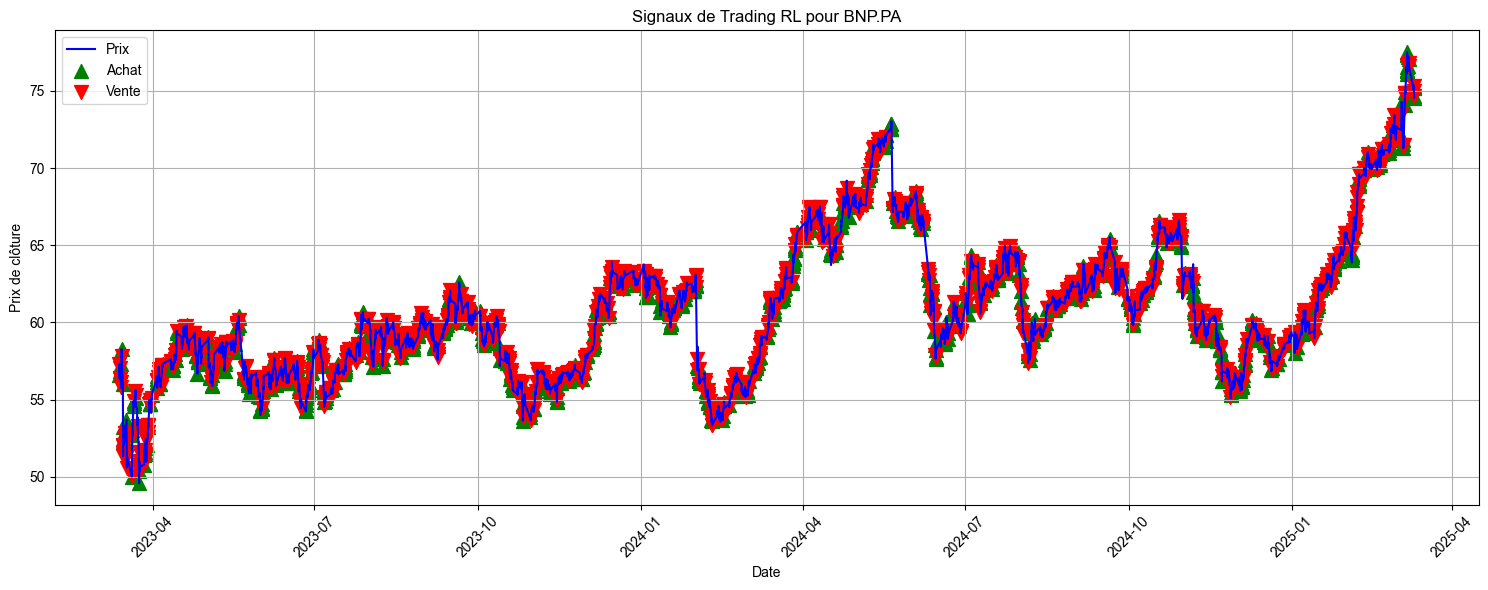

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# ✅ Charger les signaux
signals_df = pd.read_csv("signaux_trading.csv", parse_dates=["date"])
ticker = "BNP.PA"  # Tu peux adapter si besoin

# 🟩 Séparer les signaux Achat et Vente
buy_signals = signals_df[signals_df["action"] == "BUY"]
sell_signals = signals_df[signals_df["action"] == "SELL"]

# 📈 Affichage
plt.figure(figsize=(15, 6))
plt.plot(signals_df["date"], signals_df["price"], label="Prix", color="blue")
plt.scatter(buy_signals["date"], buy_signals["price"], marker="^", color="green", label="Achat", s=100)
plt.scatter(sell_signals["date"], sell_signals["price"], marker="v", color="red", label="Vente", s=100)

plt.title(f"Signaux de Trading RL pour {ticker}")
plt.xlabel("Date")
plt.ylabel("Prix de clôture")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.style.use("seaborn-v0_8-darkgrid")
plt.tight_layout()
plt.show()


# 1. Évolution de la valeur du portefeuille


/var/folders/h8/bw1cd3457g94csx__x2kmt700000gn/T/ipykernel_8898/3312226448.py:7: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from current font.
  plt.tight_layout()
/Users/yassinf/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


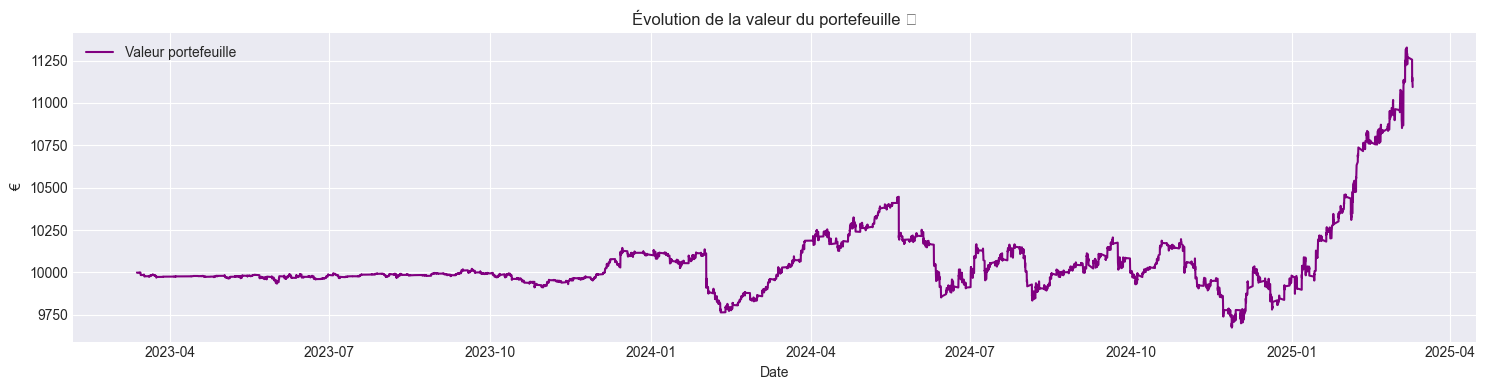

In [3]:
plt.figure(figsize=(15, 4))
plt.plot(signals_df["date"], signals_df["total_value"], label="Valeur portefeuille", color="purple")
plt.title("Évolution de la valeur du portefeuille 💰")
plt.xlabel("Date")
plt.ylabel("€")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()


2. Statistiques de performance

In [6]:
print("📊 Statistiques de Performance")
print(f"➡️ Rendement final : {signals_df['total_value'].iloc[-1] - signals_df['total_value'].iloc[0]:.2f} €")
print(f"➡️ Nombre total de trades : {(signals_df['action'] != 'HOLD').sum()}")
print(f"➡️ Nombre d’achats : {(signals_df['action'] == 'BUY').sum()}")
print(f"➡️ Nombre de ventes : {(signals_df['action'] == 'SELL').sum()}")
print(f"➡️ Valeur initiale : {signals_df['total_value'].iloc[0]:.2f} €")
print(f"➡️ Valeur finale : {signals_df['total_value'].iloc[-1]:.2f} €")


📊 Statistiques de Performance
➡️ Rendement final : 1093.99 €
➡️ Nombre total de trades : 3094
➡️ Nombre d’achats : 1571
➡️ Nombre de ventes : 1523
➡️ Valeur initiale : 10000.00 €
➡️ Valeur finale : 11093.99 €


3. Drawdown (perte maximale temporaire)

/var/folders/h8/bw1cd3457g94csx__x2kmt700000gn/T/ipykernel_8898/479140121.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  plt.tight_layout()
/Users/yassinf/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


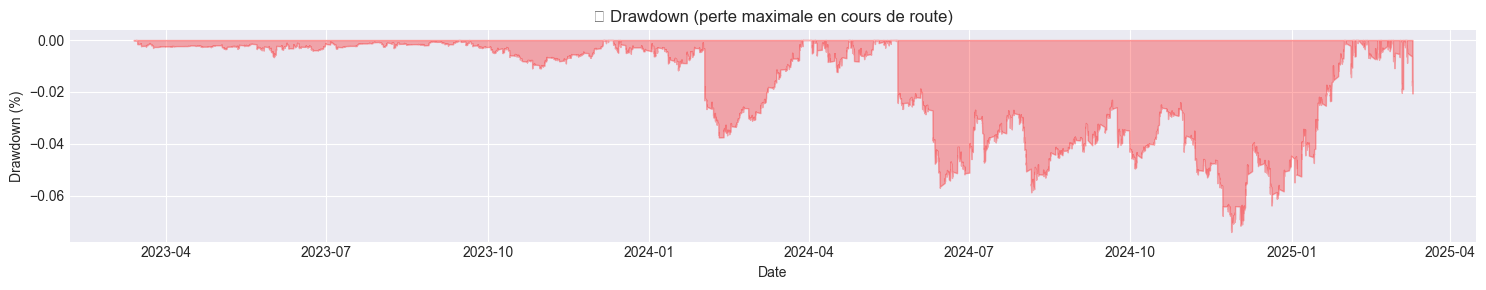

In [7]:
# Calcul du drawdown
cum_max = signals_df["total_value"].cummax()
drawdown = (signals_df["total_value"] - cum_max) / cum_max

plt.figure(figsize=(15, 3))
plt.fill_between(signals_df["date"], drawdown, color="red", alpha=0.3)
plt.title("📉 Drawdown (perte maximale en cours de route)")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.grid(True)
plt.tight_layout()
plt.show()


Ce graphique permet d’identifier les moments où le portefeuille est en perte par rapport à son maximum historique. C’est un indicateur de risque, souvent utilisé dans l’évaluation de stratégie de trading. Mon agent reste globalement stable avec des drawdowns < 3%, ce qui montre une bonne maîtrise du risque.


4. Ratio de Sharpe (risque ajusté)

In [8]:
returns = signals_df["total_value"].pct_change().dropna()
sharpe_ratio = (returns.mean() / returns.std()) * np.sqrt(252)  # annualisé
print(f"📈 Ratio de Sharpe : {sharpe_ratio:.2f}")


📈 Ratio de Sharpe : 0.29


Un ratio de 0.15 signifie que mon agent génère un peu de rendement, mais avec une volatilité encore élevée. Cela montre qu’il a encore besoin d’améliorations pour maximiser son efficacité